# IFN680 Project 4 — Case 3: Young Classifier Confidence Audit

## 1. Audit Objective

### Case context
A facial-image classifier was developed to predict whether a person appears young. The deployed system uses the model's predicted probability as a measure of confidence and automatically publishes predictions above a high-confidence threshold without human review.

During internal testing, high-confidence predictions appeared highly reliable. After deployment, however, the system began producing incorrect predictions while still assigning near-certain confidence.

### Audit question
**Does the model's reported confidence accurately reflect the probability that its predictions are correct, particularly on the external deployment distribution?**

### Initial hypothesis
The model may suffer from **confidence miscalibration**, specifically overconfidence under distribution shift.

A classifier can retain high softmax probabilities even when its predictions are unreliable. If confidence values are not calibrated on deployment-like data, a rule such as:

`high confidence → bypass human review`

may therefore be unsafe.

This remains an initial hypothesis until model confidence is compared quantitatively with empirical prediction accuracy.

### Threshold note
The official assessment brief specifies a bypass threshold of **90% confidence**, while the supplied starter notebook describes a **99% threshold**. The audit therefore treats **90% as the primary deployment threshold** and additionally reports 99% as a sensitivity analysis.

### Audit workflow
1. Load the supplied model and internal/external datasets.
2. Inspect dataset size and target-class balance.
3. Reproduce internal and external model performance.
4. Collect sample-level predicted probabilities and confidence scores.
5. Evaluate the high-confidence bypass rule directly.
6. Compare confidence with empirical accuracy using reliability diagrams.
7. Quantify calibration error.
8. Inspect confidently incorrect external predictions.
9. Form an evidence-supported diagnosis and recommendations.

## 2. Environment / Imports

The supplied Case 3 model is evaluated without retraining or modification.

The notebook retains the preprocessing used by the starter notebook and fixes random seeds for reproducibility. All Case 3 resources are stored in the `Case3/` subdirectory relative to this notebook.

In [1]:
from pathlib import Path
from collections import Counter
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# Reproducibility
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


# Device
device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")


# Project paths
ROOT_DIR = Path.cwd()
CASE_DIR = ROOT_DIR / "Case3"

DATA_ZIP_PATH = CASE_DIR / "Case3Dataset.zip"
MODEL_PATH = CASE_DIR / "resnet_frozen_best-4.pth"

EXTRACT_DIR = CASE_DIR / "_extracted"


assert CASE_DIR.exists(), (
    f"Case directory not found: {CASE_DIR}"
)

assert DATA_ZIP_PATH.exists(), (
    f"Dataset ZIP not found: {DATA_ZIP_PATH}"
)

assert MODEL_PATH.exists(), (
    f"Model weights not found: {MODEL_PATH}"
)

print(f"Case directory: {CASE_DIR}")
print(f"Dataset ZIP:    {DATA_ZIP_PATH}")
print(f"Model weights:  {MODEL_PATH}")

Using device: cuda:0
Case directory: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3
Dataset ZIP:    /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3/Case3Dataset.zip
Model weights:  /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3/resnet_frozen_best-4.pth


## 3. Load Dataset

The supplied Case 3 dataset contains separate internal and external test sets.

Both are processed using the same ImageNet preprocessing pipeline from the supplied starter notebook:

- conversion to tensor;
- resize to `224 × 224`;
- ImageNet mean normalisation.

Raw copies are also retained for later inspection of confidently incorrect predictions.

In [2]:
EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if not any(EXTRACT_DIR.iterdir()):
    with zipfile.ZipFile(
        DATA_ZIP_PATH,
        "r"
    ) as zip_ref:
        zip_ref.extractall(
            EXTRACT_DIR
        )

    print(
        f"Dataset extracted to: {EXTRACT_DIR}"
    )

else:
    print(
        f"Using existing extracted dataset at: {EXTRACT_DIR}"
    )


def find_unique_split(root: Path, split_name: str) -> Path:
    """Find one real dataset split while excluding macOS metadata folders."""

    matches = [
        path
        for path in root.rglob(split_name)
        if path.is_dir()
        and "__MACOSX" not in path.parts
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{split_name}' beneath {root}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found multiple valid '{split_name}' directories: {matches}"
        )

    return matches[0]


INTERNAL_DIR = find_unique_split(
    EXTRACT_DIR,
    "test_internal"
)

EXTERNAL_DIR = find_unique_split(
    EXTRACT_DIR,
    "test_external"
)

print(f"Internal split: {INTERNAL_DIR}")
print(f"External split: {EXTERNAL_DIR}")

Dataset extracted to: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3/_extracted
Internal split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3/_extracted/Case3Dataset/test_internal
External split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case3/_extracted/Case3Dataset/test_external


In [3]:
imagenet_means = (
    0.485,
    0.456,
    0.406
)

imagenet_stds = (
    0.229,
    0.224,
    0.225
)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(
        imagenet_means,
        imagenet_stds
    ),
])


# Raw datasets for visual inspection
test_internal_raw = torchvision.datasets.ImageFolder(
    INTERNAL_DIR
)

test_external_raw = torchvision.datasets.ImageFolder(
    EXTERNAL_DIR
)


# Model-input datasets
test_internal_dataset = torchvision.datasets.ImageFolder(
    INTERNAL_DIR,
    transform=transform
)

test_external_dataset = torchvision.datasets.ImageFolder(
    EXTERNAL_DIR,
    transform=transform
)


batch_size = 16

test_internal_loader = torch.utils.data.DataLoader(
    test_internal_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_external_loader = torch.utils.data.DataLoader(
    test_external_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


assert (
    test_internal_dataset.class_to_idx
    == test_external_dataset.class_to_idx
)

class_names = test_internal_dataset.classes


print(
    f"Internal dataset size: {len(test_internal_dataset)}"
)

print(
    f"External dataset size: {len(test_external_dataset)}"
)

print(
    f"Classes: {class_names}"
)

print(
    f"Class mapping: {test_internal_dataset.class_to_idx}"
)

Internal dataset size: 300
External dataset size: 300
Classes: ['negative', 'positive']
Class mapping: {'negative': 0, 'positive': 1}


## 4. Load Model

The supplied model uses a ResNet-18 architecture with the final fully connected layer replaced by a two-class classifier.

The supplied trained weights are loaded directly. `weights=None` is used when reconstructing the architecture because the checkpoint contains the complete trained state and no external ImageNet download is required.

In [4]:
def setup_model(
    model,
    num_classes,
    freeze_backbone=False
):
    """Adapt a ResNet classifier to the required number of classes."""

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    return model


backbone = torchvision.models.resnet18(
    weights=None
)

resnet_frozen = setup_model(
    backbone,
    num_classes=2,
    freeze_backbone=False
)


try:
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
except TypeError:
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device
    )


state_dict = (
    checkpoint["state_dict"]
    if isinstance(checkpoint, dict)
    and "state_dict" in checkpoint
    else checkpoint
)

resnet_frozen.load_state_dict(
    state_dict
)

resnet_frozen = resnet_frozen.to(
    device
)

resnet_frozen.eval()

print("Model loaded successfully.")
print(f"Output classes: {resnet_frozen.fc.out_features}")

Model loaded successfully.
Output classes: 2


## 5. Dataset Inspection

Before analysing model confidence, the target-class composition of the internal and external test sets is checked.

This establishes whether differences in aggregate performance could be influenced by a change in positive/negative class prevalence.

Because Case 3 concerns the reliability of model confidence, subsequent analysis will retain each sample's predicted probabilities, predicted class, confidence and correctness.

In [5]:
def summarise_class_balance(dataset, split_name):
    """Return class counts and proportions for an ImageFolder dataset."""

    target_counts = Counter(dataset.targets)
    total_samples = len(dataset)

    records = []

    for class_index, class_name in enumerate(dataset.classes):
        class_count = target_counts[class_index]

        records.append({
            "split": split_name,
            "class_name": class_name,
            "count": class_count,
            "proportion": class_count / total_samples,
        })

    return records


class_balance = pd.DataFrame(
    summarise_class_balance(
        test_internal_dataset,
        "internal"
    )
    + summarise_class_balance(
        test_external_dataset,
        "external"
    )
)

class_balance

,split,class_name,count,proportion
0,internal,negative,150,0.5
1,internal,positive,150,0.5
2,external,negative,150,0.5
3,external,positive,150,0.5


## 6. Baseline Model Evaluation

The supplied classifier is evaluated without modification on both datasets.

For each image, the audit retains:

- the true class;
- the predicted class;
- the probability assigned to each class;
- the confidence of the prediction, defined as the maximum softmax probability; and
- whether the prediction was correct.

These sample-level results are required because overall accuracy alone cannot determine whether a confidence-based automation rule is reliable.

In [6]:
def evaluate_classifier(
    model,
    dataloader,
    device,
    split_name
):
    """
    Evaluate the classifier and retain sample-level probabilities
    for subsequent confidence-calibration analysis.
    """

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for inputs, labels in tqdm.tqdm(
            dataloader,
            desc=f"Evaluating {split_name}"
        ):
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    labels_array = np.asarray(
        all_labels
    )

    predictions_array = np.asarray(
        all_predictions
    )

    probabilities_array = np.asarray(
        all_probabilities
    )

    confidence_array = probabilities_array.max(
        axis=1
    )

    correct_array = (
        predictions_array
        == labels_array
    )

    metrics = {
        "accuracy": accuracy_score(
            labels_array,
            predictions_array
        ),
        "precision": precision_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "recall": recall_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "f1": f1_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
    }

    return {
        "split": split_name,
        "labels": labels_array,
        "predictions": predictions_array,
        "probabilities": probabilities_array,
        "confidence": confidence_array,
        "correct": correct_array,
        "metrics": metrics,
        "confusion_matrix": confusion_matrix(
            labels_array,
            predictions_array
        ),
    }

In [7]:
internal_results = evaluate_classifier(
    resnet_frozen,
    test_internal_loader,
    device,
    "internal"
)

external_results = evaluate_classifier(
    resnet_frozen,
    test_external_loader,
    device,
    "external"
)

print("\nEvaluation complete.")

Evaluating external: 100%|██████████| 19/19 [00:01<00:00, 14.34it/s]



Evaluation complete.


In [8]:
performance_summary = pd.DataFrame([
    {
        "split": "internal",
        **internal_results["metrics"],
    },
    {
        "split": "external",
        **external_results["metrics"],
    }
])

performance_summary

,split,accuracy,precision,recall,f1
0,internal,0.973333,0.973333,0.973333,0.973333
1,external,0.593333,0.561404,0.853333,0.677249


## 7. High-Confidence Bypass Audit

The deployment system assumes that a high softmax probability implies a highly reliable prediction.

The official assessment brief specifies that predictions with **90% confidence or greater** bypass human review. The supplied starter notebook instead describes a **99% threshold**.

The primary audit therefore evaluates the official **90% threshold**, while the stricter 99% threshold is retained as a sensitivity check.

For each threshold, the following are measured:

- number of predictions eligible for automatic publication;
- proportion of the dataset bypassing review;
- empirical accuracy among bypassed predictions;
- number of incorrect predictions that would be automatically published; and
- error rate among bypassed predictions.

If the confidence score is appropriately reliable, predictions above a very high threshold should exhibit correspondingly high empirical accuracy.

In [9]:
def audit_bypass_threshold(
    results,
    threshold,
    split_name
):
    """Evaluate a confidence-based human-review bypass rule."""

    confidence = results["confidence"]
    correct = results["correct"]

    bypass_mask = (
        confidence >= threshold
    )

    bypass_count = int(
        bypass_mask.sum()
    )

    total_count = len(confidence)

    if bypass_count > 0:

        bypass_accuracy = float(
            correct[bypass_mask].mean()
        )

        incorrect_bypass_count = int(
            (~correct[bypass_mask]).sum()
        )

    else:
        bypass_accuracy = np.nan
        incorrect_bypass_count = 0

    return {
        "split": split_name,
        "threshold": threshold,
        "bypass_count": bypass_count,
        "bypass_rate": (
            bypass_count / total_count
        ),
        "bypass_accuracy": bypass_accuracy,
        "incorrect_auto_published": incorrect_bypass_count,
        "bypass_error_rate": (
            1 - bypass_accuracy
            if bypass_count > 0
            else np.nan
        ),
    }

In [10]:
bypass_summary = pd.DataFrame([
    audit_bypass_threshold(
        internal_results,
        0.90,
        "internal"
    ),

    audit_bypass_threshold(
        external_results,
        0.90,
        "external"
    ),

    audit_bypass_threshold(
        internal_results,
        0.99,
        "internal"
    ),

    audit_bypass_threshold(
        external_results,
        0.99,
        "external"
    ),
])

bypass_summary

,split,threshold,bypass_count,bypass_rate,bypass_accuracy,incorrect_auto_published,bypass_error_rate
0,internal,0.90,243,0.810000,0.995885,1,0.004115
1,external,0.90,163,0.543333,0.558282,72,0.441718
2,internal,0.99,127,0.423333,1.000000,0,0.000000
3,external,0.99,60,0.200000,0.516667,29,0.483333


### 7.1 High-confidence errors

A confidence threshold is unsafe if incorrect predictions can still enter the automated bypass.

The number of confidently incorrect predictions is therefore examined directly rather than relying only on average accuracy.

In [11]:
def summarise_high_confidence_errors(
    results,
    threshold,
    split_name
):
    """Summarise incorrect predictions above a confidence threshold."""

    high_confidence_mask = (
        results["confidence"] >= threshold
    )

    incorrect_mask = (
        ~results["correct"]
    )

    high_confidence_errors = (
        high_confidence_mask
        & incorrect_mask
    )

    return {
        "split": split_name,
        "threshold": threshold,
        "high_confidence_predictions": int(
            high_confidence_mask.sum()
        ),
        "high_confidence_errors": int(
            high_confidence_errors.sum()
        ),
        "maximum_confidence_error": (
            float(
                results["confidence"][
                    high_confidence_errors
                ].max()
            )
            if high_confidence_errors.any()
            else np.nan
        ),
    }


high_confidence_error_summary = pd.DataFrame([
    summarise_high_confidence_errors(
        internal_results,
        0.90,
        "internal"
    ),

    summarise_high_confidence_errors(
        external_results,
        0.90,
        "external"
    ),

    summarise_high_confidence_errors(
        internal_results,
        0.99,
        "internal"
    ),

    summarise_high_confidence_errors(
        external_results,
        0.99,
        "external"
    ),
])

high_confidence_error_summary

,split,threshold,high_confidence_predictions,high_confidence_errors,maximum_confidence_error
0,internal,0.90,243,1,0.955989
1,external,0.90,163,72,0.999929
2,internal,0.99,127,0,NaN
3,external,0.99,60,29,0.999929


## 8. Confidence Calibration Analysis

A well-calibrated classifier should have confidence values that correspond to empirical correctness.

For example, among predictions made with approximately 90% confidence, roughly 90% should be correct.

To test this, predictions are divided into confidence bins. For each bin, the audit calculates:

- the number of predictions;
- mean model confidence;
- empirical accuracy; and
- the calibration gap between confidence and accuracy.

A model is **overconfident** when its mean confidence is higher than its observed accuracy.

In [12]:
def calculate_calibration_table(
    results,
    n_bins=10
):
    """
    Bin predictions by confidence and compare
    mean confidence with empirical accuracy.
    """

    confidence = results["confidence"]
    correct = results["correct"].astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    records = []

    for bin_index in range(n_bins):

        lower_bound = bin_edges[bin_index]
        upper_bound = bin_edges[bin_index + 1]

        # Include confidence == 1.0 in the final bin
        if bin_index == n_bins - 1:
            bin_mask = (
                (confidence >= lower_bound)
                & (confidence <= upper_bound)
            )
        else:
            bin_mask = (
                (confidence >= lower_bound)
                & (confidence < upper_bound)
            )

        bin_count = int(
            bin_mask.sum()
        )

        if bin_count == 0:
            continue

        mean_confidence = float(
            confidence[bin_mask].mean()
        )

        empirical_accuracy = float(
            correct[bin_mask].mean()
        )

        records.append({
            "bin_lower": lower_bound,
            "bin_upper": upper_bound,
            "count": bin_count,
            "mean_confidence": mean_confidence,
            "accuracy": empirical_accuracy,
            "calibration_gap": (
                mean_confidence
                - empirical_accuracy
            ),
        })

    return pd.DataFrame(records)

In [13]:
internal_calibration = calculate_calibration_table(
    internal_results,
    n_bins=10
)

external_calibration = calculate_calibration_table(
    external_results,
    n_bins=10
)

print("Internal calibration")
display(internal_calibration)

print("\nExternal calibration")
display(external_calibration)

Internal calibration


,bin_lower,bin_upper,count,mean_confidence,accuracy,calibration_gap
0,0.5,0.6,6,0.535222,0.833333,-0.298111
1,0.6,0.7,8,0.644262,0.750000,-0.105738
2,0.7,0.8,21,0.757097,0.809524,-0.052427
3,0.8,0.9,22,0.849048,1.000000,-0.150952
4,0.9,1.0,243,0.980256,0.995885,-0.015628



External calibration


,bin_lower,bin_upper,count,mean_confidence,accuracy,calibration_gap
0,0.5,0.6,33,0.546220,0.696970,-0.150749
1,0.6,0.7,31,0.663431,0.483871,0.179560
2,0.7,0.8,24,0.752057,0.750000,0.002057
3,0.8,0.9,49,0.857186,0.632653,0.224533
4,0.9,1.0,163,0.969885,0.558282,0.411603


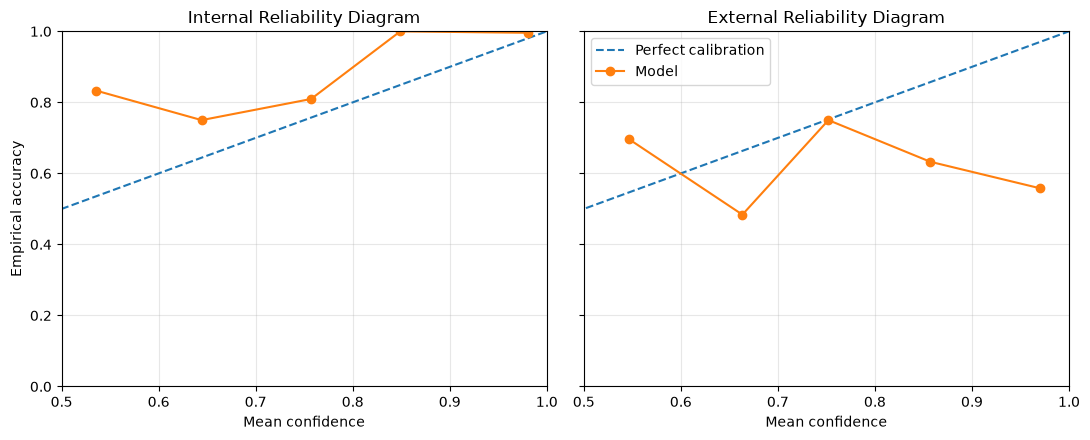

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharex=True,
    sharey=True
)

for ax, calibration_df, split_name in [
    (
        axes[0],
        internal_calibration,
        "Internal"
    ),
    (
        axes[1],
        external_calibration,
        "External"
    ),
]:

    # Perfect calibration reference
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    # Observed model calibration
    ax.plot(
        calibration_df["mean_confidence"],
        calibration_df["accuracy"],
        marker="o",
        label="Model"
    )

    ax.set_title(
        f"{split_name} Reliability Diagram"
    )

    ax.set_xlabel(
        "Mean confidence"
    )

    ax.set_xlim(
        0.5,
        1.0
    )

    ax.set_ylim(
        0.0,
        1.0
    )

    ax.grid(
        alpha=0.3
    )

axes[0].set_ylabel(
    "Empirical accuracy"
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
def expected_calibration_error(
    results,
    n_bins=10
):
    """
    Calculate Expected Calibration Error (ECE)
    using prediction confidence and correctness.
    """

    calibration_df = calculate_calibration_table(
        results,
        n_bins=n_bins
    )

    total_samples = len(
        results["confidence"]
    )

    ece = 0.0

    for _, row in calibration_df.iterrows():

        bin_weight = (
            row["count"]
            / total_samples
        )

        bin_gap = abs(
            row["mean_confidence"]
            - row["accuracy"]
        )

        ece += (
            bin_weight
            * bin_gap
        )

    return float(ece)


internal_ece = expected_calibration_error(
    internal_results
)

external_ece = expected_calibration_error(
    external_results
)

ece_summary = pd.DataFrame({
    "split": [
        "internal",
        "external"
    ],
    "ECE": [
        internal_ece,
        external_ece
    ]
})

ece_summary

,split,ECE
0,internal,0.036181
1,external,0.295613


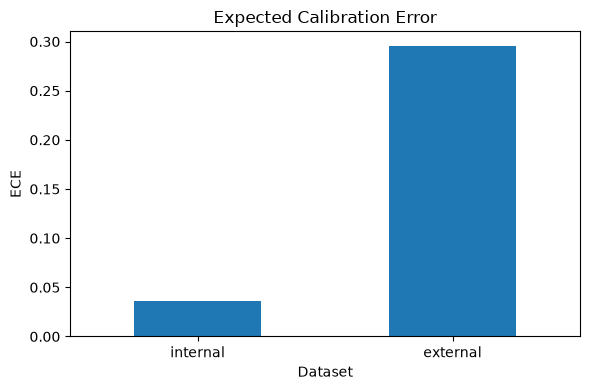

In [16]:
ax = ece_summary.plot(
    x="split",
    y="ECE",
    kind="bar",
    legend=False,
    figsize=(6, 4)
)

ax.set_title(
    "Expected Calibration Error"
)

ax.set_xlabel(
    "Dataset"
)

ax.set_ylabel(
    "ECE"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

## 9. High-Confidence Error Inspection

The calibration analysis establishes that high external confidence does not correspond to high empirical accuracy.

To verify that this failure is not produced only by predictions close to the 90% threshold, the most confident incorrect external predictions are inspected directly.

If predictions with confidence close to 100% are visibly incorrect, then the softmax score cannot safely be interpreted as a probability that the prediction is correct.

In [17]:
def build_audit_dataframe(
    dataset,
    results,
    split_name
):
    """
    Link model predictions and confidence values
    to their corresponding image files.
    """

    records = []

    for sample_index, (image_path, true_label) in enumerate(
        dataset.samples
    ):
        predicted_label = int(
            results["predictions"][sample_index]
        )

        confidence = float(
            results["confidence"][sample_index]
        )

        records.append({
            "split": split_name,
            "sample_index": sample_index,
            "filename": Path(image_path).name,
            "path": image_path,
            "true_label": int(true_label),
            "true_class": class_names[int(true_label)],
            "predicted_label": predicted_label,
            "predicted_class": class_names[predicted_label],
            "confidence": confidence,
            "correct": bool(
                results["correct"][sample_index]
            ),
        })

    return pd.DataFrame(records)


internal_audit = build_audit_dataframe(
    test_internal_raw,
    internal_results,
    "internal"
)

external_audit = build_audit_dataframe(
    test_external_raw,
    external_results,
    "external"
)

external_audit.head()

,split,sample_index,filename,path,true_label,true_class,predicted_label,predicted_class,confidence,correct
0,external,0,10255.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,1,positive,0.996971,False
1,external,1,10277.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,1,positive,0.936652,False
2,external,2,10295.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,1,positive,0.584969,False
3,external,3,1048.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,1,positive,0.982650,False
4,external,4,10540.jpg,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,1,positive,0.997482,False


In [18]:
most_confident_external_errors = (
    external_audit[
        ~external_audit["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

most_confident_external_errors[
    [
        "filename",
        "true_class",
        "predicted_class",
        "confidence",
    ]
]

,filename,true_class,predicted_class,confidence
0,3930.jpg,negative,positive,0.999929
1,1990.jpg,negative,positive,0.999804
2,5857.jpg,negative,positive,0.999658
3,8235.jpg,negative,positive,0.999519
4,2532.jpg,negative,positive,0.999416
5,3715.jpg,negative,positive,0.999404
6,17840.jpg,negative,positive,0.999346
7,86.jpg,negative,positive,0.999196
8,17283.jpg,negative,positive,0.999128
9,14954.jpg,negative,positive,0.998961


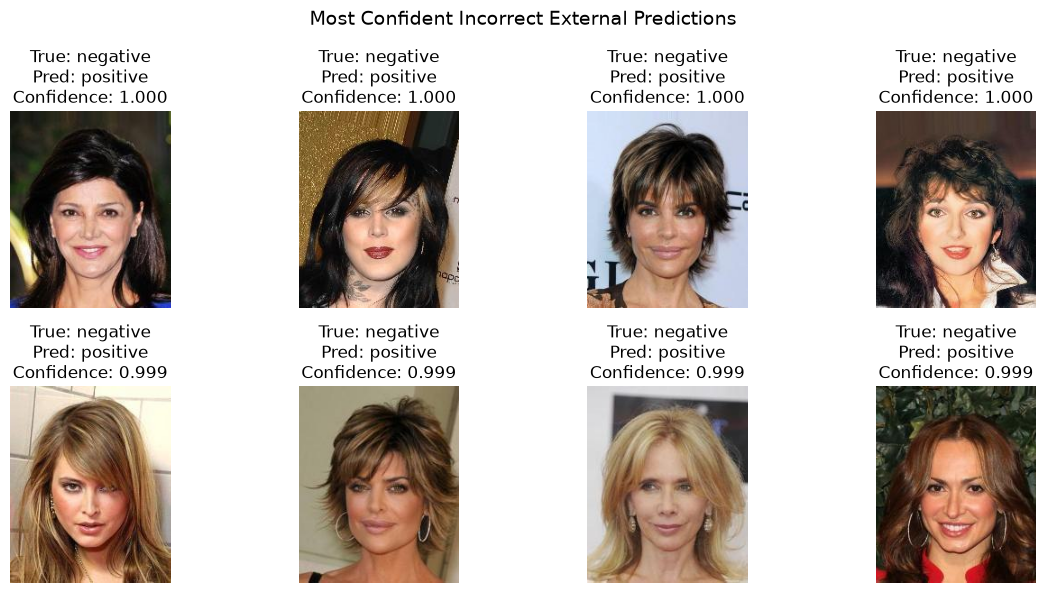

In [19]:
def show_high_confidence_errors(
    audit_dataframe,
    raw_dataset,
    n_examples=8
):
    """Display the highest-confidence incorrect predictions."""

    errors = (
        audit_dataframe[
            ~audit_dataframe["correct"]
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
        .head(n_examples)
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(12, 6)
    )

    axes = axes.flatten()

    for ax, (_, row) in zip(
        axes,
        errors.iterrows()
    ):
        image, _ = raw_dataset[
            int(row["sample_index"])
        ]

        ax.imshow(image)

        ax.set_title(
            f"True: {row['true_class']}\n"
            f"Pred: {row['predicted_class']}\n"
            f"Confidence: {row['confidence']:.3f}"
        )

        ax.axis("off")

    plt.suptitle(
        "Most Confident Incorrect External Predictions",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


show_high_confidence_errors(
    external_audit,
    test_external_raw,
    n_examples=8
)

In [20]:
confidence_by_correctness = (
    external_audit
    .groupby("correct")["confidence"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .rename(
        index={
            False: "incorrect",
            True: "correct"
        }
    )
)

confidence_by_correctness

,count,mean,median,minimum,maximum
correct,,,,,
incorrect,122,0.870792,0.935060,0.508335,0.999929
correct,178,0.845494,0.906638,0.506795,0.999959


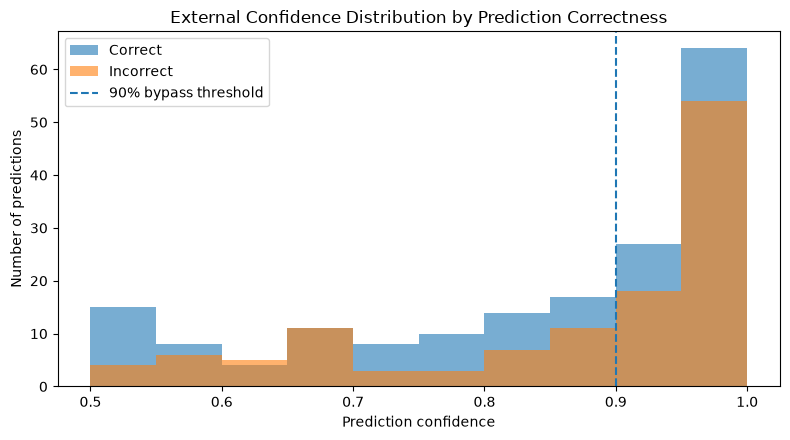

In [21]:
plt.figure(
    figsize=(8, 4.5)
)

plt.hist(
    external_audit.loc[
        external_audit["correct"],
        "confidence"
    ],
    bins=np.linspace(0.5, 1.0, 11),
    alpha=0.6,
    label="Correct"
)

plt.hist(
    external_audit.loc[
        ~external_audit["correct"],
        "confidence"
    ],
    bins=np.linspace(0.5, 1.0, 11),
    alpha=0.6,
    label="Incorrect"
)

plt.axvline(
    0.90,
    linestyle="--",
    label="90% bypass threshold"
)

plt.xlabel(
    "Prediction confidence"
)

plt.ylabel(
    "Number of predictions"
)

plt.title(
    "External Confidence Distribution by Prediction Correctness"
)

plt.legend()

plt.tight_layout()
plt.show()

### 9.1 Calibration findings

The internal and external evaluations show fundamentally different relationships between confidence and correctness.

The internal test set has an Expected Calibration Error (ECE) of **0.0362**, compared with **0.2956** on the external deployment set.

The most important failure occurs in the highest-confidence predictions:

- the external 90–100% confidence bin contains **163 predictions**;
- their mean reported confidence is **96.99%**;
- their actual accuracy is only **55.83%**; and
- the resulting overconfidence gap is **41.16 percentage points**.

In contrast, the internal 90–100% bin has a mean confidence of **98.03%** and an empirical accuracy of **99.59%**. The confidence-based automation rule therefore appeared reliable during internal development but does not generalise to the deployment distribution.

The external confidence distributions provide further evidence that confidence is not separating reliable from unreliable predictions. Incorrect predictions have a mean confidence of **87.08%** and median confidence of **93.51%**, compared with **84.55%** mean and **90.66%** median confidence for correct predictions. Therefore, incorrect external predictions are not systematically assigned lower confidence; they are slightly more confident on average.

The most confident incorrect external prediction has confidence **99.99%**, and multiple errors occur with confidence above **99.9%**. This demonstrates that even near-certain softmax probabilities cannot be interpreted as near-certain correctness on the external distribution.

Overall, the results provide strong evidence of **confidence miscalibration under distribution shift**, specifically severe overconfidence in the deployment population.

### 9.2 Direction of high-confidence errors

The most confident external errors observed above are negative samples incorrectly predicted as positive.

To determine whether this pattern is systematic rather than limited to the displayed examples, high-confidence errors are grouped by their true and predicted classes.

In [22]:
def summarise_error_directions(
    audit_dataframe,
    threshold
):
    """Count directions of incorrect predictions above a confidence threshold."""

    high_confidence_errors = audit_dataframe[
        (~audit_dataframe["correct"])
        & (audit_dataframe["confidence"] >= threshold)
    ]

    summary = (
        high_confidence_errors
        .groupby(
            ["true_class", "predicted_class"]
        )
        .size()
        .reset_index(name="count")
    )

    summary["threshold"] = threshold

    return summary


error_direction_summary = pd.concat(
    [
        summarise_error_directions(
            external_audit,
            0.90
        ),
        summarise_error_directions(
            external_audit,
            0.99
        ),
    ],
    ignore_index=True
)

error_direction_summary

,true_class,predicted_class,count,threshold
0,negative,positive,68,0.90
1,positive,negative,4,0.90
2,negative,positive,29,0.99


## 10. Audit Diagnosis

### Technical diagnosis

The Case 3 deployment failure is caused by **severe confidence miscalibration under distribution shift**, specifically external overconfidence.

The classifier's softmax probability is being treated operationally as though it represents the probability that a prediction is correct. This relationship approximately holds on the internal development distribution, but breaks down on the external deployment distribution.

### Evidence

1. **Large performance degradation**
   - Internal accuracy: **97.33%**
   - External accuracy: **59.33%**

2. **Calibration degrades substantially**
   - Internal Expected Calibration Error (ECE): **0.0362**
   - External ECE: **0.2956**

3. **Extreme overconfidence occurs exactly where the bypass operates**
   - The external 90–100% confidence bin contains **163 predictions**.
   - Their mean confidence is **96.99%**.
   - Their empirical accuracy is only **55.83%**.
   - This produces an overconfidence gap of **41.16 percentage points**.

4. **The same confidence range appears reliable internally**
   - Internal 90–100% predictions have mean confidence **98.03%**.
   - Their empirical accuracy is **99.59%**.
   - This explains why the bypass appeared safe during development.

5. **Incorrect external predictions remain highly confident**
   - Incorrect predictions have mean confidence **87.08%** and median confidence **93.51%**.
   - Correct predictions have mean confidence **84.55%** and median confidence **90.66%**.
   - The most confident incorrect prediction has confidence **99.99%**.

6. **Near-certain errors are directly observed**
   - Multiple external errors receive probabilities above **99.9%**, demonstrating that high softmax probability is not a reliable indicator of correctness on the deployment distribution.

### Conclusion

The system's technical flaw is therefore not simply that the classifier makes external errors. The critical failure is that **confidence remains high when accuracy collapses**.

The High-Confidence Bypass assumes that high confidence reliably identifies low-risk predictions. This assumption is valid on the internal distribution but false after deployment shift, causing incorrect predictions to bypass human review automatically.

## 11. Recommendations

### 1. Disable the current confidence-only bypass
Predictions should not automatically bypass human review solely because their raw softmax confidence exceeds 90% or 99%.

The external audit demonstrates that even near-certain predictions can be incorrect.

### 2. Calibrate confidence using representative deployment-like validation data
Apply a post-hoc calibration method such as **temperature scaling** using a separate validation dataset representative of the deployment population.

The calibration parameters must be estimated on validation data rather than the external audit test set to avoid test-set leakage.

### 3. Revalidate the automation threshold after calibration
The bypass threshold should be selected using empirical deployment-like validation results rather than assuming that a nominal confidence value corresponds directly to accuracy.

For example, the engineering team should determine the threshold required to achieve a predefined acceptable error rate among automatically published predictions.

### 4. Address the underlying distribution-shift performance failure
Calibration can make confidence values more meaningful, but it does **not** repair the classifier's external accuracy.

The external accuracy of **59.33%** indicates that the predictive model itself also requires investigation using more representative training data, validation data and deployment testing.

### 5. Monitor calibration after deployment
Track reliability diagrams, Expected Calibration Error, high-confidence error rates and bypass accuracy over time.

A significant change in these measures should trigger human review or suspension of automated publication.

### Audit limitations

Expected Calibration Error depends on the selected confidence-bin boundaries. The 10-bin ECE used here follows a standard reliability-diagram approach, but different binning strategies may produce slightly different numerical values. The large internal-to-external difference and severe overconfidence in the highest-confidence bin are nevertheless sufficiently large that the overall conclusion is not dependent on a small change in binning.

The audit also identifies **confidence miscalibration under distribution shift**, but does not establish the precise source of that distribution shift because the training dataset is not supplied. Additional analysis of the original training data and deployment population would be required to determine why classification accuracy itself decreases.

Finally, this audit evaluates the existing model rather than fitting a calibration correction. Any proposed calibration method should be trained on a separate deployment-representative validation set and evaluated on unseen test data.